<center><h1>Sengottuvel_ArunKarthik_Final_Project</h1></center>

Name: Arun Karthik Sengottuvel
<br>
Github Username: arunkarthik2000
<br>
USC ID: 9981450691

## 1. Transfer Learning for Image Classification

#### Import packages

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import random

import tensorflow as tf
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0, VGG16
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

In [3]:
import warnings
warnings.filterwarnings('ignore')

### (b) Data Exploration and Pre-processing

**Note:- I uploaded my data to Kaggle and used it to run my notebook**

In [4]:
# train_dir = '../data/seg_train'
# test_dir = '../data/seg_test'

train_dir = '/kaggle/input/dsml-project/data/seg_train'
test_dir = '/kaggle/input/dsml-project/data/seg_test'

train_counts = {}
for category in os.listdir(train_dir):
    category_path = os.path.join(train_dir, category)
    if os.path.isdir(category_path):
        train_counts[category] = len(os.listdir(category_path))

test_counts = {}
for category in os.listdir(test_dir):
    category_path = os.path.join(test_dir, category)
    if os.path.isdir(category_path):
        test_counts[category] = len(os.listdir(category_path))

print("Training set distribution:", train_counts)
print("Testing set distribution:", test_counts)

Training set distribution: {'mountain': 2512, 'street': 2382, 'buildings': 2191, 'sea': 2274, 'forest': 2271, 'glacier': 2404}
Testing set distribution: {'mountain': 525, 'street': 501, 'buildings': 437, 'sea': 510, 'forest': 474, 'glacier': 553}


In [5]:
IMAGE_SIZE = (128, 128)

X_train = []
y_train = []
X_test = []
y_test = []

classes = ['forest', 'buildings', 'glacier', 'street', 'mountain', 'sea']
class_to_index = {'forest': 0, 'buildings': 1, 'glacier': 2, 'street': 3, 'mountain': 4, 'sea': 5}

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, IMAGE_SIZE)  
                X_train.append(img)
                y_train.append(class_to_index[cls])

X_train = np.array(X_train)
y_train = np.array(y_train)

for cls in classes:
    cls_path = os.path.join(test_dir, cls)
    if os.path.isdir(cls_path):
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, IMAGE_SIZE)  
                X_test.append(img)
                y_test.append(class_to_index[cls])

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (14034, 128, 128, 3)
Testing data shape: (3000, 128, 128, 3)


In [6]:
y_train_encoded = to_categorical(y_train, num_classes=len(class_to_index))
y_test_encoded = to_categorical(y_test, num_classes=len(class_to_index))

print(f"One-hot encoded training labels shape: {y_train_encoded.shape}")
print(f"One-hot encoded testing labels shape: {y_test_encoded.shape}")

One-hot encoded training labels shape: (14034, 6)
One-hot encoded testing labels shape: (3000, 6)


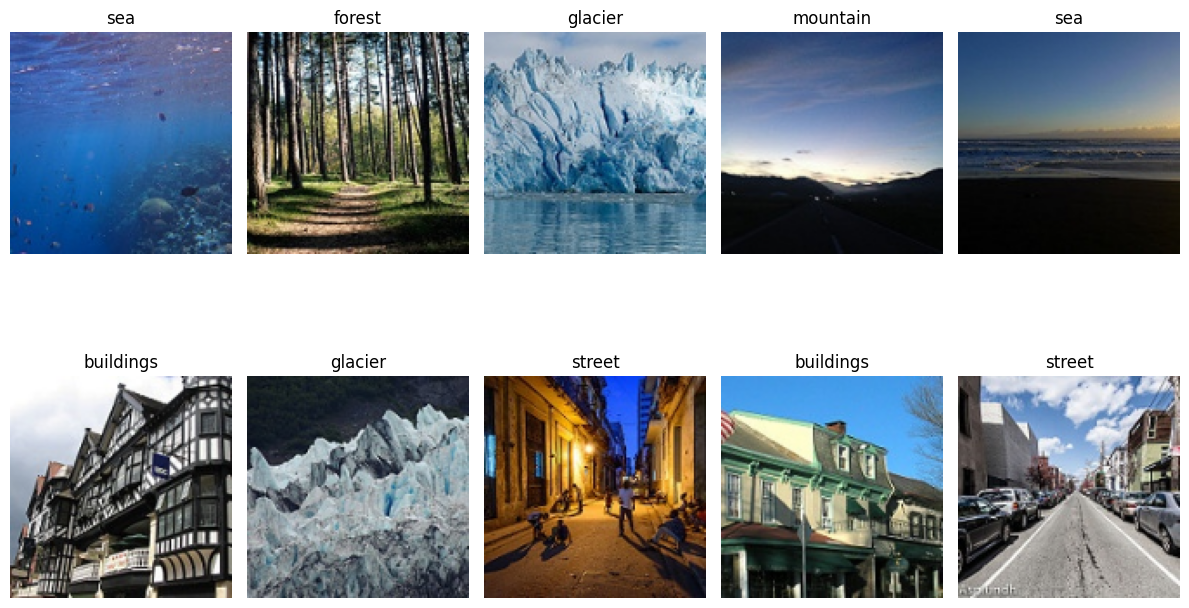

In [7]:
plt.figure(figsize=(12, 8))

random_indices = random.sample(range(len(X_train)), 10)

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(cv2.cvtColor(X_train[idx], cv2.COLOR_BGR2RGB))
    plt.title(list(class_to_index.keys())[y_train[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()

### (c) Transfer Learning

For applying image augmentation techniques, I referred to ChatGPT.

**“How to apply image augmentation to data in batches?” ChatGPT prompt.**

In [8]:
train_data, train_labels = X_train, y_train

X_train, X_val, y_train, y_val = train_test_split(
    train_data, train_labels, test_size=0.2, stratify=train_labels, random_state=42
)

y_train_encoded = to_categorical(y_train, num_classes=len(class_to_index))
y_val_encoded = to_categorical(y_val, num_classes=len(class_to_index))


train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator()

test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(
    X_train, y_train_encoded,
    batch_size=32,
    shuffle=False
)

validation_generator = validation_datagen.flow(
    X_val, y_val_encoded, 
    batch_size=32, 
    shuffle=False
)

test_generator = test_datagen.flow(
    X_test, y_test_encoded, 
    batch_size=32, 
    shuffle=False
)

#### ResNet50

In [9]:
resnet50_base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

for layer in resnet50_base_model.layers:
    layer.trainable = False

x = Flatten()(resnet50_base_model.output)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
resnet50_output_layer = Dense(6, activation='softmax')(x)

resnet50_model = Model(inputs=resnet50_base_model.input, outputs=resnet50_output_layer)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

resnet50_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 31,979,142 (121.99 MB)

 Trainable params: 8,390,918 (32.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

For applying early stopping, I referred to ChatGPT.

**“How to apply early stopping after a certain number of epochs?” ChatGPT prompt.**

In [10]:
class CustomEarlyStopping(Callback):
    def __init__(self, min_epochs, patience=10):
        super().__init__()
        self.min_epochs = min_epochs
        self.patience = patience
        self.best = float('inf')
        self.wait = 0
        self.stopped_epoch = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get('val_loss')
        if epoch >= self.min_epochs - 1:
            if current < self.best:
                self.best = current
                self.wait = 0
                self.best_weights = self.model.get_weights()
            else:
                self.wait += 1
                if self.wait >= self.patience:
                    self.stopped_epoch = epoch
                    self.model.stop_training = True
                    print(f'\nEpoch {epoch+1}: early stopping')
                    self.model.set_weights(self.best_weights)

early_stopping_resnet50 = CustomEarlyStopping(min_epochs=50, patience=10)
model_checkpoint_resnet50 = ModelCheckpoint(filepath='best_resnet50_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

resnet50_history = resnet50_model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // train_generator.batch_size,
    epochs=100,  
    validation_data=validation_generator,
    validation_steps=len(X_val) // validation_generator.batch_size,
    callbacks=[
        early_stopping_resnet50,  
        model_checkpoint_resnet50  
    ]
)

Epoch 1/100


I0000 00:00:1734293678.398194      92 service.cc:145] XLA service 0x78366c001970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1734293678.398257      92 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1734293678.398263      92 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  3/350 ━━━━━━━━━━━━━━━━━━━━ 26s 77ms/step - accuracy: 0.3351 - loss: 7.1020   

I0000 00:00:1734293685.027803      92 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7828 - loss: 3.3406
Epoch 1: val_loss improved from inf to 1.10258, saving model to best_resnet50_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 63s 142ms/step - accuracy: 0.7829 - loss: 3.3373 - val_accuracy: 0.8987 - val_loss: 1.1026
Epoch 2/100
  1/350 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7812 - loss: 1.4086
Epoch 2: val_loss did not improve from 1.10258
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7812 - loss: 1.4086 - val_accuracy: 0.8261 - val_loss: 1.1443
Epoch 3/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8369 - loss: 1.2164
Epoch 3: val_loss improved from 1.10258 to 0.98843, saving model to best_resnet50_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.8369 - loss: 1.2163 - val_accuracy: 0.8825 - val_loss: 0.9884
Epoch 4/100
  1/350 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8750 - loss: 1.1777
Epoch 4: val_loss improved from 0.98843 to 0.97483, saving model to be

In [11]:
best_resnet50_model = load_model('best_resnet50_model.keras')

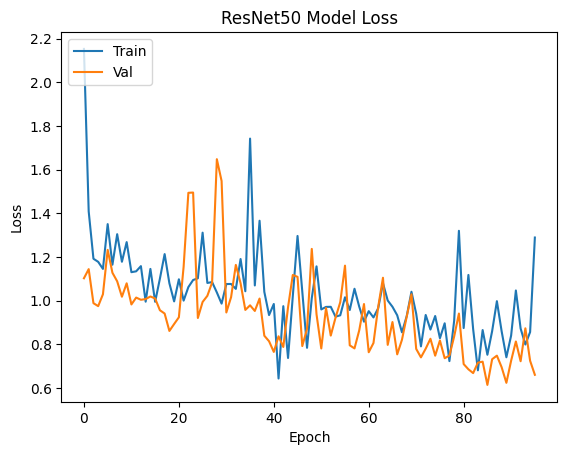

In [12]:
plt.plot(resnet50_history.history['loss'])
plt.plot(resnet50_history.history['val_loss'])
plt.title('ResNet50 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [13]:
resnet50_train_loss, resnet50_train_accuracy = best_resnet50_model.evaluate(train_generator)
resnet50_y_pred_train = best_resnet50_model.predict(train_generator)
resnet50_y_pred_train_classes = np.argmax(resnet50_y_pred_train, axis=1)

resnet50_train_precision = precision_score(y_train, resnet50_y_pred_train_classes, average='macro')
resnet50_train_recall = recall_score(y_train, resnet50_y_pred_train_classes, average='macro')
resnet50_train_f1 = f1_score(y_train, resnet50_y_pred_train_classes, average='macro')
resnet50_train_auc = roc_auc_score(np.eye(len(classes))[y_train], resnet50_y_pred_train, multi_class='ovr')

resnet50_train_class_report = classification_report(
    y_train,                   
    resnet50_y_pred_train_classes,      
    target_names=classes       
)

print("\n\nResNet50 Classification Report (Train Data):")
print(resnet50_train_class_report)

351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 112ms/step - accuracy: 0.8571 - loss: 0.8272
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 113ms/step


ResNet50 Classification Report (Train Data):
              precision    recall  f1-score   support

      forest       0.98      0.94      0.96      1817
   buildings       0.85      0.91      0.88      1753
     glacier       0.71      0.88      0.78      1923
      street       0.91      0.86      0.89      1906
    mountain       0.83      0.78      0.80      2009
         sea       0.92      0.78      0.84      1819

    accuracy                           0.86     11227
   macro avg       0.87      0.86      0.86     11227
weighted avg       0.87      0.86      0.86     11227



In [14]:
resnet50_val_loss, resnet50_val_accuracy = best_resnet50_model.evaluate(validation_generator)
resnet50_y_pred_val = best_resnet50_model.predict(validation_generator)
resnet50_y_pred_val_classes = np.argmax(resnet50_y_pred_val, axis=1)

resnet50_val_precision = precision_score(y_val, resnet50_y_pred_val_classes, average='macro')
resnet50_val_recall = recall_score(y_val, resnet50_y_pred_val_classes, average='macro')
resnet50_val_f1 = f1_score(y_val, resnet50_y_pred_val_classes, average='macro')
resnet50_val_auc = roc_auc_score(np.eye(len(classes))[y_val], resnet50_y_pred_val, multi_class='ovr')

resnet50_val_class_report = classification_report(
    y_val,
    resnet50_y_pred_val_classes,
    target_names=classes
)

print("\n\nResNet50 Classification Report (Validation Data):")
print(resnet50_val_class_report)

88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8977 - loss: 0.7168
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step


ResNet50 Classification Report (Validation Data):
              precision    recall  f1-score   support

      forest       0.99      0.96      0.98       454
   buildings       0.89      0.93      0.91       438
     glacier       0.77      0.89      0.82       481
      street       0.93      0.93      0.93       476
    mountain       0.86      0.78      0.82       503
         sea       0.97      0.92      0.94       455

    accuracy                           0.90      2807
   macro avg       0.90      0.90      0.90      2807
weighted avg       0.90      0.90      0.90      2807



In [15]:
resnet50_test_loss, resnet50_test_accuracy = best_resnet50_model.evaluate(test_generator)
resnet50_y_pred_test = best_resnet50_model.predict(test_generator)
resnet50_y_pred_test_classes = np.argmax(resnet50_y_pred_test, axis=1)

resnet50_test_precision = precision_score(y_test, resnet50_y_pred_test_classes, average='macro')
resnet50_test_recall = recall_score(y_test, resnet50_y_pred_test_classes, average='macro')
resnet50_test_f1 = f1_score(y_test, resnet50_y_pred_test_classes, average='macro')
resnet50_test_auc = roc_auc_score(np.eye(len(classes))[y_test], resnet50_y_pred_test, multi_class='ovr')

resnet50_test_class_report = classification_report(
    y_test,
    resnet50_y_pred_test_classes,
    target_names=classes
)

print("\n\nResNet50 Classification Report (Test Data):")
print(resnet50_test_class_report)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9282 - loss: 0.6365
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step


ResNet50 Classification Report (Test Data):
              precision    recall  f1-score   support

      forest       0.98      0.98      0.98       474
   buildings       0.89      0.92      0.90       437
     glacier       0.81      0.88      0.84       553
      street       0.92      0.91      0.92       501
    mountain       0.86      0.80      0.83       525
         sea       0.94      0.91      0.93       510

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



In [16]:
resnet50_metrics_data = {
    "Dataset": ["Train", "Validation", "Test"],
    "Precision": [
        resnet50_train_precision,
        resnet50_val_precision,
        resnet50_test_precision,
    ],
    "Recall": [
        resnet50_train_recall,
        resnet50_val_recall,
        resnet50_test_recall,
    ],
    "F1-Score": [
        resnet50_train_f1,
        resnet50_val_f1,
        resnet50_test_f1,
    ],
    "AUC": [
        resnet50_train_auc,
        resnet50_val_auc,
        resnet50_test_auc,
    ],
}

resnet50_metrics_table = pd.DataFrame(resnet50_metrics_data)

print("===== ResNet50 Model Performance Metrics =====\n")
print(resnet50_metrics_table.to_string(index=False))

===== ResNet50 Model Performance Metrics =====

   Dataset  Precision   Recall  F1-Score      AUC
     Train   0.867082 0.857997  0.859550 0.983045
Validation   0.902685 0.899269  0.899646 0.988902
      Test   0.900600 0.899233  0.899413 0.989200


#### ResNet101

In [17]:
resnet101_base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

for layer in resnet101_base_model.layers:
    layer.trainable = False

x = Flatten()(resnet101_base_model.output)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
resnet101_output_layer = Dense(6, activation='softmax')(x)

resnet101_model = Model(inputs=resnet101_base_model.input, outputs=resnet101_output_layer)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

resnet101_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet101_model.summary()

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 51,049,606 (194.74 MB)

 Trainable params: 8,390,918 (32.01 MB)

 Non-trainable params: 42,658,688 (162.73 MB)

In [18]:
early_stopping_resnet101 = CustomEarlyStopping(min_epochs=50, patience=10)
model_checkpoint_resnet101 = ModelCheckpoint(filepath='best_resnet101_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

resnet101_history = resnet101_model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // train_generator.batch_size,
    epochs=100, 
    validation_data=validation_generator,
    validation_steps=len(X_val) // validation_generator.batch_size,
    callbacks=[
        early_stopping_resnet101,
        model_checkpoint_resnet101
    ]
)

Epoch 1/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7859 - loss: 3.2852
Epoch 1: val_loss improved from inf to 1.24613, saving model to best_resnet101_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 73s 158ms/step - accuracy: 0.7860 - loss: 3.2821 - val_accuracy: 0.8477 - val_loss: 1.2461
Epoch 2/100
  1/350 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - accuracy: 0.7500 - loss: 1.4316
Epoch 2: val_loss improved from 1.24613 to 1.19139, saving model to best_resnet101_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7500 - loss: 1.4316 - val_accuracy: 0.8261 - val_loss: 1.1914
Epoch 3/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8217 - loss: 1.2729
Epoch 3: val_loss improved from 1.19139 to 1.13983, saving model to best_resnet101_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 46s 129ms/step - accuracy: 0.8217 - loss: 1.2728 - val_accuracy: 0.8707 - val_loss: 1.1398
Epoch 4/100
  1/350 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.8750 - loss: 1.2294
Epoch

In [19]:
best_resnet101_model = load_model('best_resnet101_model.keras')

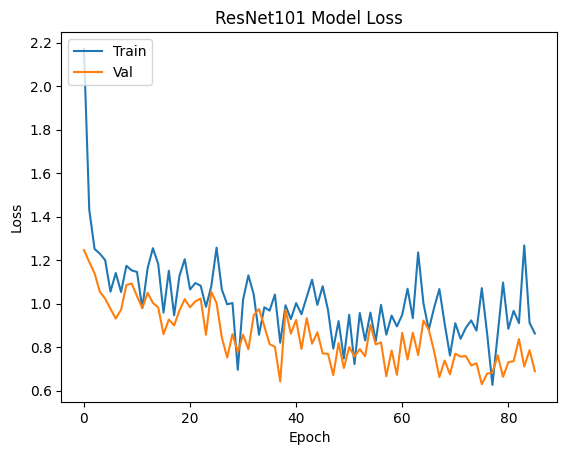

In [25]:
plt.plot(resnet101_history.history['loss'])
plt.plot(resnet101_history.history['val_loss'])
plt.title('ResNet101 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [21]:
resnet101_train_loss, resnet101_train_accuracy = best_resnet101_model.evaluate(train_generator)
resnet101_y_pred_train = best_resnet101_model.predict(train_generator)
resnet101_y_pred_train_classes = np.argmax(resnet101_y_pred_train, axis=1)

resnet101_train_precision = precision_score(y_train, resnet101_y_pred_train_classes, average='macro')
resnet101_train_recall = recall_score(y_train, resnet101_y_pred_train_classes, average='macro')
resnet101_train_f1 = f1_score(y_train, resnet101_y_pred_train_classes, average='macro')
resnet101_train_auc = roc_auc_score(np.eye(len(classes))[y_train], resnet101_y_pred_train, multi_class='ovr')

resnet101_train_class_report = classification_report(
    y_train,                   
    resnet101_y_pred_train_classes,      
    target_names=classes       
)

print("\n\nResNet101 Classification Report (Train Data):")
print(resnet101_train_class_report)

351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 114ms/step - accuracy: 0.8548 - loss: 0.8022
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step


ResNet101 Classification Report (Train Data):
              precision    recall  f1-score   support

      forest       0.99      0.96      0.97      1817
   buildings       0.88      0.90      0.89      1753
     glacier       0.90      0.60      0.72      1923
      street       0.87      0.91      0.89      1906
    mountain       0.72      0.90      0.80      2009
         sea       0.85      0.90      0.88      1819

    accuracy                           0.86     11227
   macro avg       0.87      0.86      0.86     11227
weighted avg       0.87      0.86      0.86     11227



In [22]:
resnet101_val_loss, resnet101_val_accuracy = best_resnet101_model.evaluate(validation_generator)
resnet101_y_pred_val = best_resnet101_model.predict(validation_generator)
resnet101_y_pred_val_classes = np.argmax(resnet101_y_pred_val, axis=1)

resnet101_val_precision = precision_score(y_val, resnet101_y_pred_val_classes, average='macro')
resnet101_val_recall = recall_score(y_val, resnet101_y_pred_val_classes, average='macro')
resnet101_val_f1 = f1_score(y_val, resnet101_y_pred_val_classes, average='macro')
resnet101_val_auc = roc_auc_score(np.eye(len(classes))[y_val], resnet101_y_pred_val, multi_class='ovr')

resnet101_val_class_report = classification_report(
    y_val,                   
    resnet101_y_pred_val_classes,      
    target_names=classes       
)

print("\n\nResNet101 Classification Report (Validation Data):")
print(resnet101_val_class_report)

88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.8910 - loss: 0.7379
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step


ResNet101 Classification Report (Validation Data):
              precision    recall  f1-score   support

      forest       0.99      0.96      0.98       454
   buildings       0.95      0.92      0.93       438
     glacier       0.91      0.66      0.76       481
      street       0.93      0.97      0.95       476
    mountain       0.77      0.89      0.83       503
         sea       0.86      0.97      0.91       455

    accuracy                           0.89      2807
   macro avg       0.90      0.90      0.89      2807
weighted avg       0.90      0.89      0.89      2807



In [23]:
resnet101_test_loss, resnet101_test_accuracy = best_resnet101_model.evaluate(test_generator)
resnet101_y_pred_test = best_resnet101_model.predict(test_generator)
resnet101_y_pred_test_classes = np.argmax(resnet101_y_pred_test, axis=1)

resnet101_test_precision = precision_score(y_test, resnet101_y_pred_test_classes, average='macro')
resnet101_test_recall = recall_score(y_test, resnet101_y_pred_test_classes, average='macro')
resnet101_test_f1 = f1_score(y_test, resnet101_y_pred_test_classes, average='macro')
resnet101_test_auc = roc_auc_score(np.eye(len(classes))[y_test], resnet101_y_pred_test, multi_class='ovr')

resnet101_test_class_report = classification_report(
    y_test,                   
    resnet101_y_pred_test_classes,      
    target_names=classes       
)

print("\n\nResNet101 Classification Report (Test Data):")
print(resnet101_test_class_report)

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8951 - loss: 0.6882
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step


ResNet101 Classification Report (Test Data):
              precision    recall  f1-score   support

      forest       1.00      0.99      0.99       474
   buildings       0.91      0.90      0.90       437
     glacier       0.92      0.63      0.74       553
      street       0.91      0.94      0.92       501
    mountain       0.75      0.90      0.82       525
         sea       0.87      0.97      0.92       510

    accuracy                           0.88      3000
   macro avg       0.89      0.89      0.88      3000
weighted avg       0.89      0.88      0.88      3000



In [24]:
resnet101_metrics_data = {
    "Dataset": ["Train", "Validation", "Test"],
    "Precision": [
        resnet101_train_precision,
        resnet101_val_precision,
        resnet101_test_precision,
    ],
    "Recall": [
        resnet101_train_recall,
        resnet101_val_recall,
        resnet101_test_recall,
    ],
    "F1-Score": [
        resnet101_train_f1,
        resnet101_val_f1,
        resnet101_test_f1,
    ],
    "AUC": [
        resnet101_train_auc,
        resnet101_val_auc,
        resnet101_test_auc,
    ],
}

resnet101_metrics_table = pd.DataFrame(resnet101_metrics_data)

print("===== ResNet101 Model Performance Metrics =====\n")
print(resnet101_metrics_table.to_string(index=False))

===== ResNet101 Model Performance Metrics =====

   Dataset  Precision   Recall  F1-Score      AUC
     Train   0.869378 0.859807  0.857638 0.983548
Validation   0.901524 0.895745  0.893750 0.988401
      Test   0.891501 0.887259  0.882959 0.988844


### EfficientNetB0

In [26]:
efficientnetb0_base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

for layer in efficientnetb0_base_model.layers:
    layer.trainable = False

x = Flatten()(efficientnetb0_base_model.output)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
efficientnetb0_output_layer = Dense(6, activation='softmax')(x)

efficientnetb0_model = Model(inputs=efficientnetb0_base_model.input, outputs=efficientnetb0_output_layer)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

efficientnetb0_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

efficientnetb0_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 128,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │        512 │ block1a_se_excit

 Total params: 9,295,273 (35.46 MB)

 Trainable params: 5,245,190 (20.01 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [27]:
early_stopping_efficientnetb0 = CustomEarlyStopping(min_epochs=50, patience=10)
model_checkpoint_efficientnetb0 = ModelCheckpoint(filepath='best_efficientnetb0_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

efficientnetb0_history = efficientnetb0_model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // train_generator.batch_size,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=len(X_val) // validation_generator.batch_size,
    callbacks=[
        early_stopping_efficientnetb0,
        model_checkpoint_efficientnetb0
    ]
)

Epoch 1/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7457 - loss: 4.2400
Epoch 1: val_loss improved from inf to 1.56211, saving model to best_efficientnetb0_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 89s 174ms/step - accuracy: 0.7458 - loss: 4.2360 - val_accuracy: 0.8653 - val_loss: 1.5621
Epoch 2/100
  1/350 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9062 - loss: 1.4464
Epoch 2: val_loss improved from 1.56211 to 1.49950, saving model to best_efficientnetb0_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9062 - loss: 1.4464 - val_accuracy: 0.9130 - val_loss: 1.4995
Epoch 3/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8106 - loss: 1.6569
Epoch 3: val_loss improved from 1.49950 to 1.49780, saving model to best_efficientnetb0_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.8106 - loss: 1.6568 - val_accuracy: 0.8423 - val_loss: 1.4978
Epoch 4/100
  1/350 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8750 - loss:

In [28]:
best_efficientnetb0_model = load_model('best_efficientnetb0_model.keras')

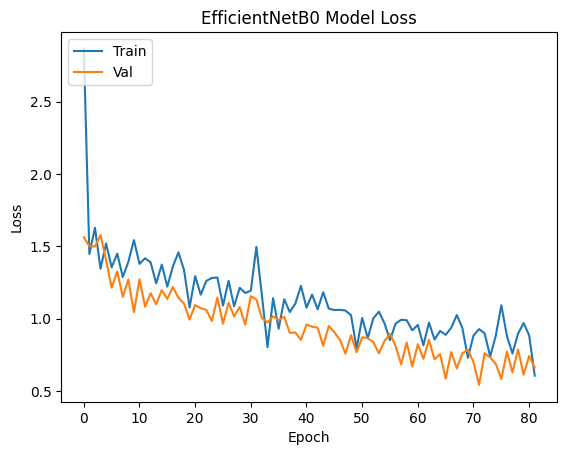

In [29]:
plt.plot(efficientnetb0_history.history['loss'])
plt.plot(efficientnetb0_history.history['val_loss'])
plt.title('EfficientNetB0 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [31]:
efficientnetb0_train_loss, efficientnetb0_train_accuracy = best_efficientnetb0_model.evaluate(train_generator)
efficientnetb0_y_pred_train = best_efficientnetb0_model.predict(train_generator)
efficientnetb0_y_pred_train_classes = np.argmax(efficientnetb0_y_pred_train, axis=1)

efficientnetb0_train_precision = precision_score(y_train, efficientnetb0_y_pred_train_classes, average='macro')
efficientnetb0_train_recall = recall_score(y_train, efficientnetb0_y_pred_train_classes, average='macro')
efficientnetb0_train_f1 = f1_score(y_train, efficientnetb0_y_pred_train_classes, average='macro')
efficientnetb0_train_auc = roc_auc_score(np.eye(len(classes))[y_train], efficientnetb0_y_pred_train, multi_class='ovr')

efficientnetb0_train_class_report = classification_report(
    y_train,                   
    efficientnetb0_y_pred_train_classes,      
    target_names=classes       
)

print("\n\nEfficientNetB0 Classification Report (Train Data):")
print(efficientnetb0_train_class_report)

351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - accuracy: 0.8229 - loss: 0.8574
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step


EfficientNetB0 Classification Report (Train Data):
              precision    recall  f1-score   support

      forest       0.92      0.98      0.95      1817
   buildings       0.89      0.85      0.87      1753
     glacier       0.81      0.68      0.74      1923
      street       0.85      0.93      0.89      1906
    mountain       0.82      0.64      0.72      2009
         sea       0.70      0.92      0.79      1819

    accuracy                           0.83     11227
   macro avg       0.83      0.83      0.83     11227
weighted avg       0.83      0.83      0.82     11227



In [32]:
efficientnetb0_val_loss, efficientnetb0_val_accuracy = best_efficientnetb0_model.evaluate(validation_generator)
efficientnetb0_y_pred_val = best_efficientnetb0_model.predict(validation_generator)
efficientnetb0_y_pred_val_classes = np.argmax(efficientnetb0_y_pred_val, axis=1)

efficientnetb0_val_precision = precision_score(y_val, efficientnetb0_y_pred_val_classes, average='macro')
efficientnetb0_val_recall = recall_score(y_val, efficientnetb0_y_pred_val_classes, average='macro')
efficientnetb0_val_f1 = f1_score(y_val, efficientnetb0_y_pred_val_classes, average='macro')
efficientnetb0_val_auc = roc_auc_score(np.eye(len(classes))[y_val], efficientnetb0_y_pred_val, multi_class='ovr')

efficientnetb0_val_class_report = classification_report(
    y_val,
    efficientnetb0_y_pred_val_classes,
    target_names=classes
)

print("\n\nEfficientNetB0 Classification Report (Validation Data):")
print(efficientnetb0_val_class_report)

88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8831 - loss: 0.7009
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step


EfficientNetB0 Classification Report (Validation Data):
              precision    recall  f1-score   support

      forest       0.97      0.98      0.97       454
   buildings       0.91      0.90      0.90       438
     glacier       0.79      0.80      0.80       481
      street       0.91      0.96      0.93       476
    mountain       0.86      0.74      0.79       503
         sea       0.85      0.92      0.89       455

    accuracy                           0.88      2807
   macro avg       0.88      0.88      0.88      2807
weighted avg       0.88      0.88      0.88      2807



In [33]:
efficientnetb0_test_loss, efficientnetb0_test_accuracy = best_efficientnetb0_model.evaluate(test_generator)
efficientnetb0_y_pred_test = best_efficientnetb0_model.predict(test_generator)
efficientnetb0_y_pred_test_classes = np.argmax(efficientnetb0_y_pred_test, axis=1)

efficientnetb0_test_precision = precision_score(y_test, efficientnetb0_y_pred_test_classes, average='macro')
efficientnetb0_test_recall = recall_score(y_test, efficientnetb0_y_pred_test_classes, average='macro')
efficientnetb0_test_f1 = f1_score(y_test, efficientnetb0_y_pred_test_classes, average='macro')
efficientnetb0_test_auc = roc_auc_score(np.eye(len(classes))[y_test], efficientnetb0_y_pred_test, multi_class='ovr')

efficientnetb0_test_class_report = classification_report(
    y_test,
    efficientnetb0_y_pred_test_classes,
    target_names=classes
)

print("\n\nEfficientNetB0 Classification Report (Test Data):")
print(efficientnetb0_test_class_report)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.9072 - loss: 0.6134
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step


EfficientNetB0 Classification Report (Test Data):
              precision    recall  f1-score   support

      forest       0.98      0.99      0.98       474
   buildings       0.87      0.86      0.87       437
     glacier       0.83      0.78      0.80       553
      street       0.88      0.95      0.91       501
    mountain       0.84      0.76      0.80       525
         sea       0.86      0.92      0.89       510

    accuracy                           0.87      3000
   macro avg       0.87      0.88      0.87      3000
weighted avg       0.87      0.87      0.87      3000



In [34]:
efficientnetb0_metrics_data = {
    "Dataset": ["Train", "Validation", "Test"],
    "Precision": [
        efficientnetb0_train_precision,
        efficientnetb0_val_precision,
        efficientnetb0_test_precision,
    ],
    "Recall": [
        efficientnetb0_train_recall,
        efficientnetb0_val_recall,
        efficientnetb0_test_recall,
    ],
    "F1-Score": [
        efficientnetb0_train_f1,
        efficientnetb0_val_f1,
        efficientnetb0_test_f1,
    ],
    "AUC": [
        efficientnetb0_train_auc,
        efficientnetb0_val_auc,
        efficientnetb0_test_auc,
    ],
}

efficientnetb0_metrics_table = pd.DataFrame(efficientnetb0_metrics_data)

print("===== EfficientNetB0 Model Performance Metrics =====\n")
print(efficientnetb0_metrics_table.to_string(index=False))

===== EfficientNetB0 Model Performance Metrics =====

   Dataset  Precision   Recall  F1-Score      AUC
     Train   0.832569 0.830914  0.825858 0.975751
Validation   0.880795 0.882757  0.880666 0.986527
      Test   0.874255 0.876624  0.874594 0.985564


### VGG16

In [36]:
vgg16_base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

for layer in vgg16_base_model.layers:
    layer.trainable = False

x = Flatten()(vgg16_base_model.output)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
vgg16_output_layer = Dense(6, activation='softmax')(x)

vgg16_model = Model(inputs=vgg16_base_model.input, outputs=vgg16_output_layer)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

vgg16_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 16,814,662 (64.14 MB)

 Trainable params: 2,099,462 (8.01 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [37]:
early_stopping_vgg16 = CustomEarlyStopping(min_epochs=50, patience=10)
model_checkpoint_vgg16 = ModelCheckpoint(filepath='best_vgg16_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

vgg16_history = vgg16_model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // train_generator.batch_size,
    epochs=100, 
    validation_data=validation_generator,
    validation_steps=len(X_val) // validation_generator.batch_size,
    callbacks=[
        early_stopping_vgg16,
        model_checkpoint_vgg16
    ]
)

Epoch 1/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7708 - loss: 3.3723
Epoch 1: val_loss improved from inf to 1.10145, saving model to best_vgg16_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 68s 152ms/step - accuracy: 0.7710 - loss: 3.3692 - val_accuracy: 0.8879 - val_loss: 1.1014
Epoch 2/100
  1/350 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.8438 - loss: 1.2262
Epoch 2: val_loss improved from 1.10145 to 0.94630, saving model to best_vgg16_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8438 - loss: 1.2262 - val_accuracy: 0.9130 - val_loss: 0.9463
Epoch 3/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8388 - loss: 1.1716
Epoch 3: val_loss improved from 0.94630 to 0.89020, saving model to best_vgg16_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 44s 123ms/step - accuracy: 0.8388 - loss: 1.1714 - val_accuracy: 0.9009 - val_loss: 0.8902
Epoch 4/100
  1/350 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.8750 - loss: 0.9800
Epoch 4: val_loss

In [41]:
best_vgg16_model = load_model('best_vgg16_model.keras')  

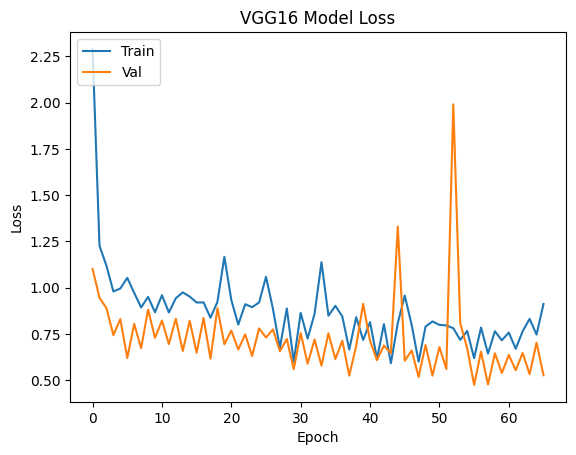

In [42]:
plt.plot(vgg16_history.history['loss'])
plt.plot(vgg16_history.history['val_loss'])
plt.title('VGG16 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [43]:
vgg16_train_loss, vgg16_train_accuracy = best_vgg16_model.evaluate(train_generator)
vgg16_y_pred_train = best_vgg16_model.predict(train_generator)
vgg16_y_pred_train_classes = np.argmax(vgg16_y_pred_train, axis=1)

vgg16_train_precision = precision_score(y_train, vgg16_y_pred_train_classes, average='macro')
vgg16_train_recall = recall_score(y_train, vgg16_y_pred_train_classes, average='macro')
vgg16_train_f1 = f1_score(y_train, vgg16_y_pred_train_classes, average='macro')
vgg16_train_auc = roc_auc_score(np.eye(len(classes))[y_train], vgg16_y_pred_train, multi_class='ovr')

vgg16_train_class_report = classification_report(
    y_train,                   
    vgg16_y_pred_train_classes,      
    target_names=classes       
)

print("\n\nVGG16 Classification Report (Train Data):")
print(vgg16_train_class_report)

351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 108ms/step - accuracy: 0.8389 - loss: 0.7944
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step


VGG16 Classification Report (Train Data):
              precision    recall  f1-score   support

      forest       0.99      0.90      0.95      1817
   buildings       0.80      0.94      0.86      1753
     glacier       0.73      0.83      0.78      1923
      street       0.87      0.86      0.87      1906
    mountain       0.90      0.66      0.76      2009
         sea       0.83      0.91      0.87      1819

    accuracy                           0.85     11227
   macro avg       0.86      0.85      0.85     11227
weighted avg       0.86      0.85      0.85     11227



In [44]:
vgg16_val_loss, vgg16_val_accuracy = best_vgg16_model.evaluate(validation_generator)
vgg16_y_pred_val = best_vgg16_model.predict(validation_generator)
vgg16_y_pred_val_classes = np.argmax(vgg16_y_pred_val, axis=1)

vgg16_val_precision = precision_score(y_val, vgg16_y_pred_val_classes, average='macro')
vgg16_val_recall = recall_score(y_val, vgg16_y_pred_val_classes, average='macro')
vgg16_val_f1 = f1_score(y_val, vgg16_y_pred_val_classes, average='macro')
vgg16_val_auc = roc_auc_score(np.eye(len(classes))[y_val], vgg16_y_pred_val, multi_class='ovr')

vgg16_val_class_report = classification_report(
    y_val,
    vgg16_y_pred_val_classes,
    target_names=classes
)

print("\n\nVGG16 Classification Report (Validation Data):")
print(vgg16_val_class_report)

88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8908 - loss: 0.6650
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step


VGG16 Classification Report (Validation Data):
              precision    recall  f1-score   support

      forest       0.99      0.95      0.97       454
   buildings       0.88      0.94      0.91       438
     glacier       0.80      0.85      0.82       481
      street       0.92      0.91      0.92       476
    mountain       0.87      0.76      0.81       503
         sea       0.88      0.94      0.91       455

    accuracy                           0.89      2807
   macro avg       0.89      0.89      0.89      2807
weighted avg       0.89      0.89      0.89      2807



In [45]:
vgg16_test_loss, vgg16_test_accuracy = best_vgg16_model.evaluate(test_generator)
vgg16_y_pred_test = best_vgg16_model.predict(test_generator)
vgg16_y_pred_test_classes = np.argmax(vgg16_y_pred_test, axis=1)

vgg16_test_precision = precision_score(y_test, vgg16_y_pred_test_classes, average='macro')
vgg16_test_recall = recall_score(y_test, vgg16_y_pred_test_classes, average='macro')
vgg16_test_f1 = f1_score(y_test, vgg16_y_pred_test_classes, average='macro')
vgg16_test_auc = roc_auc_score(np.eye(len(classes))[y_test], vgg16_y_pred_test, multi_class='ovr')

vgg16_test_class_report = classification_report(
    y_test,
    vgg16_y_pred_test_classes,
    target_names=classes
)

print("\n\nVGG16 Classification Report (Test Data):")
print(vgg16_test_class_report)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.9170 - loss: 0.6025
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step


VGG16 Classification Report (Test Data):
              precision    recall  f1-score   support

      forest       0.98      0.97      0.98       474
   buildings       0.87      0.91      0.89       437
     glacier       0.83      0.83      0.83       553
      street       0.90      0.90      0.90       501
    mountain       0.88      0.78      0.83       525
         sea       0.89      0.95      0.92       510

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000



In [46]:
vgg16_metrics_data = {
    "Dataset": ["Train", "Validation", "Test"],
    "Precision": [
        vgg16_train_precision,
        vgg16_val_precision,
        vgg16_test_precision,
    ],
    "Recall": [
        vgg16_train_recall,
        vgg16_val_recall,
        vgg16_test_recall,
    ],
    "F1-Score": [
        vgg16_train_f1,
        vgg16_val_f1,
        vgg16_test_f1,
    ],
    "AUC": [
        vgg16_train_auc,
        vgg16_val_auc,
        vgg16_test_auc,
    ],
}

vgg16_metrics_table = pd.DataFrame(vgg16_metrics_data)

print("===== VGG16 Model Performance Metrics =====\n")
print(vgg16_metrics_table.to_string(index=False))

===== VGG16 Model Performance Metrics =====

   Dataset  Precision   Recall  F1-Score      AUC
     Train   0.855379 0.850475  0.847907 0.982521
Validation   0.891474 0.892121  0.890630 0.988011
      Test   0.891127 0.892232  0.890867 0.987818


### Comparison

#### Overall Performance:
- **ResNet50** consistently performs the best across all metrics on the test set:
  - **Highest Accuracy (90%)**.
  - **Best Precision (0.9006)** and F1-score (0.8994).
  - **Highest AUC (0.9892)**.
- **ResNet101** follows closely but underperforms compared to ResNet50 in both F1-score and overall accuracy (**88% vs. 90%**).
- **EfficientNetB0** shows slightly lower performance overall, particularly in precision (**0.8743**) and recall (**0.8766**), and has the lowest AUC (**0.9856**).
- **VGG16** achieves performance close to ResNet101 but is slightly less accurate than ResNet50.

#### Class-Level Analysis:
- **ResNet50** has strong class-specific F1-scores and recall, particularly excelling in classes like **forest (98%)** and **sea (93%)**.
- **ResNet101** struggles with the **glacier** class, achieving only **63% recall**, which negatively impacts its F1-score for the class and overall performance.
- **EfficientNetB0** shows moderate performance across all classes but doesn't excel in any specific category.
- **VGG16** has balanced performance but is outperformed by ResNet50 in most categories.
